# Portfolio and Folio Event Uncertainty by Training Size

CSV-first comparison notebook. This starts from the saved OpenQuake postrisk CSV outputs in `risk/tmp`, uses the saved `risk_by_event_*.csv` files for portfolio event counts, and uses folio-level aggregation outputs for AAL/PML comparison maps.


In [18]:
from pathlib import Path
import os
from html import escape

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
})

In [19]:
# User-facing knobs
BASE_DIR = Path("/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/tmp_foglio")
OUT_DIR = Path("/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results")
OQ_EXPORTS_DIR = OUT_DIR / "oq_exports"

# Use "p50" for median. Other available columns include mean, p05, p16, p84, p95.
STAT = "p84"

# Portfolio structural value used in the original notebook for PML loss ratios.
TOTAL_VALUE = 28_491_684_200
EVENT_COUNT_THRESHOLD = 500

# Available sizes discovered in tmp_const. Edit the list if you want a subset/order.
SIZES = [225, 529, 892, 1658, 3454, 7071]
SIZE_LABELS = {
    225: "0.4%",
    529: "1%",
    892: "1.8%",
    1658: "3.3%",
    3454: "7%",
    7071: "13%",
}

CURVES_FILE = "tsunami_portfolio_curves_stats.csv"
AAL_FILE = "tsunami_portfolio_aal_stats.csv"
SAVE_OUTPUTS = True

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
def stat_column(stat: str) -> str:
    aliases = {
        "median": "p50",
        "med": "p50",
        "q50": "p50",
        "avg": "mean",
        "average": "mean",
    }
    return aliases.get(stat.lower(), stat)


def size_percent_label(size: int) -> str:
    return SIZE_LABELS.get(size, f"{100 * size / 53_550:.1f}%")


def read_curve(path: Path, stat: str = STAT, total_value: float = TOTAL_VALUE) -> pd.DataFrame:
    stat = stat_column(stat)
    df = pd.read_csv(path)
    required = {"return_period", stat}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    df = df[["return_period", "poe", stat]].copy()
    df = df.rename(columns={stat: "loss"})
    df["loss_ratio"] = df["loss"] / total_value
    return df.sort_values("return_period")


def read_aal(path: Path, stat: str = STAT, total_value: float = TOTAL_VALUE) -> float:
    stat = stat_column(stat)
    df = pd.read_csv(path)
    if stat not in df.columns:
        raise ValueError(f"{path} is missing column: {stat}")
    return float(df[stat].iloc[0]) / total_value


def size_paths(size: int) -> dict:
    root = BASE_DIR / str(size)
    return {
        "mean": root / "mean" / CURVES_FILE,
        "sigmaminus": root / "sigmaminus" / CURVES_FILE,
        "sigmaplus": root / "sigmaplus" / CURVES_FILE,
    }


def load_size_curves(size: int, stat: str = STAT) -> dict:
    paths = size_paths(size)
    return {name: read_curve(path, stat) for name, path in paths.items()}


def run_directory(run_name, size=None) -> Path:
    if isinstance(run_name, (int, np.integer)) and size is None:
        size = int(run_name)
        run_name = "mean"
    if str(run_name) == "true":
        return BASE_DIR / "true"
    if size is None:
        raise ValueError("size is required for emulation runs")
    return BASE_DIR / str(size) / str(run_name)


def risk_by_event_path(run_name, size=None):
    paths = sorted(run_directory(run_name, size).glob("risk_by_event_*.csv"))
    return paths[0] if paths else None


def read_risk_by_event(run_name, size=None) -> pd.DataFrame:
    path = risk_by_event_path(run_name, size)
    if path is None:
        raise FileNotFoundError(f"No risk_by_event_*.csv found for run={run_name}, size={size}")
    return pd.read_csv(path, comment="#")


true_curve = read_curve(BASE_DIR / "true" / CURVES_FILE, STAT)
true_aal_ratio = read_aal(BASE_DIR / "true" / AAL_FILE, STAT)

available_sizes = []
for size in SIZES:
    if all(path.exists() for path in size_paths(size).values()):
        available_sizes.append(size)
    else:
        print(f"Skipping {size}: missing one or more curve CSVs")

available_sizes

[225, 529, 892, 1658, 3454, 7071]

/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/portfolio_loss_ratio_size_1658_p84.png


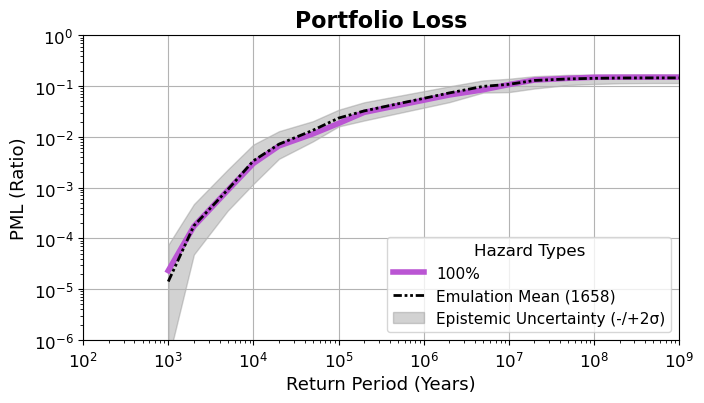

In [22]:
def plot_portfolio_comparison(size: int, stat: str = STAT, save: bool = False):
    curves = load_size_curves(size, stat)
    x = true_curve["return_period"]

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(x, true_curve["loss_ratio"], label="100%", color="mediumorchid", linewidth=4)
    ax.plot(
        curves["mean"]["return_period"],
        curves["mean"]["loss_ratio"],
        label=f"Emulation Mean ({size})",
        color="black",
        linestyle=(0, (3, 1, 1, 1, 1, 1)),
        linewidth=2,
    )
    ax.fill_between(
        curves["mean"]["return_period"].to_numpy(),
        curves["sigmaminus"]["loss_ratio"].to_numpy(),
        curves["sigmaplus"]["loss_ratio"].to_numpy(),
        color="0.5",
        alpha=0.35,
        label="Epistemic Uncertainty (-/+2σ)",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e2, 1e9)
    ax.set_ylim(1e-6, 1)
    ax.grid(True, which="major", color="0.7", linewidth=0.8)
    ax.set_title("Portfolio Loss", weight="bold")
    ax.set_xlabel("Return Period (Years)")
    ax.set_ylabel("PML (Ratio)")
    ax.legend(title="Hazard Types", loc="lower right", frameon=True)
    fig.tight_layout()

    if save:
        out = OUT_DIR / f"portfolio_loss_ratio_size_{size}_{stat_column(stat)}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print(out)
    return fig, ax


# Single-size plot, matching the style of the existing notebook figure.
plot_portfolio_comparison(1658, STAT, save=SAVE_OUTPUTS);

In [ ]:
def plot_all_sizes(stat: str = STAT, save: bool = False):
    # Use a professional color palette
    colors = ['k', 'b', 'r', 'g', 'm']

    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.plot(
        true_curve["return_period"],
        true_curve["loss_ratio"],
        label="100%",
        color="mediumorchid",
        linewidth=5,
    )

    for color, size in zip(colors, available_sizes):
        mean_curve = load_size_curves(size, stat)["mean"]
        ax.plot(
            mean_curve["return_period"],
            mean_curve["loss_ratio"],
            label=f"Mean {size} ({size_percent_label(size)})",
            color=color,
            linewidth=2,
            alpha=0.85,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e3, 1e9)
    ax.set_ylim(1e-4, 1)
    ax.grid(True, which="major", color="0.7", linewidth=0.8)
    ax.set_title(f"Portfolio Loss by Training Size ({stat_column(stat)})", weight="bold")
    ax.set_xlabel("Return Period (Years)")
    ax.set_ylabel("PML (Ratio)")
    ax.legend(loc="lower right", frameon=True, ncol=1)
    fig.tight_layout()

    if save:
        out = OUT_DIR / f"portfolio_loss_ratio_all_sizes_{stat_column(stat)}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print(out)
    return fig, ax


plot_all_sizes(STAT, save=SAVE_OUTPUTS);

In [73]:
def summarize_aal_by_size(stat: str = STAT) -> pd.DataFrame:
    rows = [{"size": "true", "run": "true", "aal_ratio": true_aal_ratio}]
    for size in available_sizes:
        for run in ["mean", "sigmaminus", "sigmaplus"]:
            aal_path = BASE_DIR / str(size) / run / AAL_FILE
            rows.append({"size": size, "run": run, "aal_ratio": read_aal(aal_path, stat)})
    return pd.DataFrame(rows)


aal_summary = summarize_aal_by_size(STAT)
aal_summary

,size,run,aal_ratio
0,true,true,1.329570e-06
1,225,mean,1.905566e-06
2,225,sigmaminus,7.964577e-07
3,225,sigmaplus,4.410114e-06
4,529,mean,1.604820e-06
5,529,sigmaminus,7.257787e-07
6,529,sigmaplus,3.081162e-06
7,892,mean,1.569648e-06
8,892,sigmaminus,7.585903e-07
9,892,sigmaplus,2.930774e-06


In [74]:
def count_loss_events(run_name, threshold: float = EVENT_COUNT_THRESHOLD, size=None):
    path = risk_by_event_path(run_name, size)
    if path is not None:
        df = pd.read_csv(path, comment="#")
        loss_col = "loss" if "loss" in df.columns else df.columns[-1]
        return int((df[loss_col] > threshold).sum())

    legacy_name = run_name if size is None else size
    legacy_path = OQ_EXPORTS_DIR / f"1_event_only_loss_{legacy_name}.csv"
    if not legacy_path.exists():
        return None
    df = pd.read_csv(legacy_path)
    loss_col = "loss" if "loss" in df.columns else df.columns[-1]
    return int((df[loss_col] > threshold).sum())


def fmt_int(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "-"
    return f"{int(round(value)):,}"


def fmt_eur(value):
    return f"{int(round(value)):,}€"


def fmt_pct(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "-"
    return f"{100 * value:+.1f}%".replace("+", "")


def build_portfolio_table(stat: str = STAT) -> pd.DataFrame:
    true_aal = read_aal(BASE_DIR / "true" / AAL_FILE, stat, total_value=1.0)
    true_aalr = true_aal / TOTAL_VALUE
    rows = [{
        "Hazard Type": "HPC-Based",
        "No of Loss Events": fmt_int(count_loss_events("true")),
        "AAL": fmt_eur(true_aal),
        "AALR (10^-7)": f"{true_aalr / 1e-7:.2f}",
        "Rel. Error": "-",
        "Uncertainty (-2σ, +2σ)": "-",
    }]

    for size in available_sizes:
        mean_aal = read_aal(BASE_DIR / str(size) / "mean" / AAL_FILE, stat, total_value=1.0)
        lo_aal = read_aal(BASE_DIR / str(size) / "sigmaminus" / AAL_FILE, stat, total_value=1.0)
        hi_aal = read_aal(BASE_DIR / str(size) / "sigmaplus" / AAL_FILE, stat, total_value=1.0)

        mean_aalr = mean_aal / TOTAL_VALUE
        lo_aalr = lo_aal / TOTAL_VALUE
        hi_aalr = hi_aal / TOTAL_VALUE

        mean_err = (mean_aal - true_aal) / true_aal
        lo_err = (lo_aal - true_aal) / true_aal
        hi_err = (hi_aal - true_aal) / true_aal

        rows.append({
            "Hazard Type": f"Emulation ({size_percent_label(size)})",
            "No of Loss Events": fmt_int(count_loss_events(size)),
            "AAL": fmt_eur(mean_aal),
            "AALR (10^-7)": f"{mean_aalr / 1e-7:.2f}",
            "Rel. Error": fmt_pct(mean_err),
            "Uncertainty (-2σ, +2σ)": (
                f"AAL {fmt_eur(lo_aal)} to {fmt_eur(hi_aal)}; "
                f"AALR {lo_aalr / 1e-7:.2f} to {hi_aalr / 1e-7:.2f}; "
                f"Err {fmt_pct(lo_err)} to {fmt_pct(hi_err)}"
            ),
        })

    return pd.DataFrame(rows)


portfolio_table = build_portfolio_table(STAT)
portfolio_table

,Hazard Type,No of Loss Events,AAL,AALR (10^-7),Rel. Error,"Uncertainty (-2σ, +2σ)"
0,HPC-Based,"30,168","37,882€",13.30,-,-
1,Emulation (0.4%),"53,550","54,293€",19.06,43.3%,"AAL 22,692€ to 125,652€; AALR 7.96 to 44.10; E..."
2,Emulation (1%),"35,269","45,724€",16.05,20.7%,"AAL 20,679€ to 87,788€; AALR 7.26 to 30.81; Er..."
3,Emulation (1.8%),"30,031","44,722€",15.70,18.1%,"AAL 21,614€ to 83,503€; AALR 7.59 to 29.31; Er..."
4,Emulation (3.3%),"29,359","44,785€",15.72,18.2%,"AAL 23,769€ to 74,881€; AALR 8.34 to 26.28; Er..."
5,Emulation (7%),"29,144","41,548€",14.58,9.7%,"AAL 24,039€ to 66,467€; AALR 8.44 to 23.33; Er..."
6,Emulation (13%),"29,449","41,336€",14.51,9.1%,"AAL 24,640€ to 64,734€; AALR 8.65 to 22.72; Er..."


In [75]:
def portfolio_table_html(table: pd.DataFrame) -> str:
    header = "".join(f"<th>{escape(str(col))}</th>" for col in table.columns)
    rows = []
    for _, row in table.iterrows():
        cells = "".join(f"<td>{escape(str(value))}</td>" for value in row)
        rows.append(f"<tr>{cells}</tr>")
    body = "".join(rows)
    return f"""
    <style>
      .portfolio-summary {{ border-collapse: collapse; font-family: serif; font-size: 15px; }}
      .portfolio-summary th {{ border-top: 2px solid black; border-bottom: 1px solid black; padding: 8px 14px; text-align: center; }}
      .portfolio-summary td {{ padding: 7px 14px; text-align: center; }}
      .portfolio-summary td:first-child {{ text-align: left; }}
      .portfolio-summary tr:last-child td {{ border-bottom: 2px solid black; }}
    </style>
    <table class="portfolio-summary"><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>
    """


display(HTML(portfolio_table_html(portfolio_table)))

if SAVE_OUTPUTS:
    table_out = OUT_DIR / f"portfolio_summary_table_{stat_column(STAT)}.csv"
    portfolio_table.to_csv(table_out, index=False)
    print(table_out)

Hazard Type,No of Loss Events,AAL,AALR (10^-7),Rel. Error,"Uncertainty (-2σ, +2σ)"
HPC-Based,"30,168","37,882€",13.30,-,-
Emulation (0.4%),"53,550","54,293€",19.06,43.3%,"AAL 22,692€ to 125,652€; AALR 7.96 to 44.10; Err -40.1% to 231.7%"
Emulation (1%),"35,269","45,724€",16.05,20.7%,"AAL 20,679€ to 87,788€; AALR 7.26 to 30.81; Err -45.4% to 131.7%"
Emulation (1.8%),"30,031","44,722€",15.70,18.1%,"AAL 21,614€ to 83,503€; AALR 7.59 to 29.31; Err -42.9% to 120.4%"
Emulation (3.3%),"29,359","44,785€",15.72,18.2%,"AAL 23,769€ to 74,881€; AALR 8.34 to 26.28; Err -37.3% to 97.7%"
Emulation (7%),"29,144","41,548€",14.58,9.7%,"AAL 24,039€ to 66,467€; AALR 8.44 to 23.33; Err -36.5% to 75.5%"
Emulation (13%),"29,449","41,336€",14.51,9.1%,"AAL 24,640€ to 64,734€; AALR 8.65 to 22.72; Err -35.0% to 70.9%"


/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/portfolio_summary_table_p84.csv


In [ ]:
def plot_aal_by_size(stat: str = STAT, save: bool = False):
    df = summarize_aal_by_size(stat)
    mean = df[df["run"] == "mean"].copy()
    lo = df[df["run"] == "sigmaminus"].set_index("size")
    hi = df[df["run"] == "sigmaplus"].set_index("size")

    x = mean["size"].astype(int).to_numpy()
    y = mean["aal_ratio"].to_numpy()
    ylo = lo.loc[x, "aal_ratio"].to_numpy()
    yhi = hi.loc[x, "aal_ratio"].to_numpy()

    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    ax.axhline(true_aal_ratio, color="mediumorchid", linewidth=3, label="100%")
    ax.plot(x, y, color="black", marker="o", linewidth=2, label="Emulation Mean")
    ax.fill_between(x, ylo, yhi, color="0.5", alpha=0.35, label="Epistemic Uncertainty (-/+2σ)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="major", color="0.75", linewidth=0.8)
    ax.set_title(f"Portfolio AAL by Training Size ({stat_column(stat)})", weight="bold")
    ax.set_xlabel("Training Size")
    ax.set_ylabel("AAL (Ratio)")
    ax.legend(frameon=True)
    fig.tight_layout()

    if save:
        out = OUT_DIR / f"portfolio_aal_ratio_sizes_{stat_column(stat)}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print(out)
    return fig, ax


plot_aal_by_size(STAT, save=SAVE_OUTPUTS);

In [ ]:
def animate_portfolio_sizes(stat: str = STAT, save_gif: bool = True):
    fig, ax = plt.subplots(figsize=(8, 5))

    def draw_frame(i):
        ax.clear()
        size = available_sizes[i]
        size_label = size_percent_label(size)
        curves = load_size_curves(size, stat)

        ax.plot(true_curve["return_period"], true_curve["loss_ratio"], label="100%", color="mediumorchid", linewidth=4)
        ax.plot(
            curves["mean"]["return_period"],
            curves["mean"]["loss_ratio"],
            label=f"Emulation Mean ({size_label})",
            color="black",
            linestyle=(0, (3, 1, 1, 1, 1, 1)),
            linewidth=2,
        )
        ax.fill_between(
            curves["mean"]["return_period"].to_numpy(),
            curves["sigmaminus"]["loss_ratio"].to_numpy(),
            curves["sigmaplus"]["loss_ratio"].to_numpy(),
            color="0.5",
            alpha=0.35,
            label="Epistemic Uncertainty (-/+2σ)",
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(1e3, 1e9)
        ax.set_ylim(1e-4, 1)
        ax.grid(True, which="major", color="0.7", linewidth=0.8)
        ax.set_title(f"Portfolio Loss - Size {size_label} ({stat_column(stat)})", weight="bold")
        ax.set_xlabel("Return Period (Years)")
        ax.set_ylabel("PML (Ratio)")
        ax.legend(title="Hazard Types", loc="lower right", frameon=True)

    anim = FuncAnimation(fig, draw_frame, frames=len(available_sizes), interval=1200, repeat=True)
    plt.close(fig)

    if save_gif:
        out = OUT_DIR / f"portfolio_loss_ratio_sizes_{stat_column(stat)}.gif"
        anim.save(out, writer=PillowWriter(fps=1), dpi=160)
        print(out)

    return anim


anim = animate_portfolio_sizes(STAT, save_gif=SAVE_OUTPUTS)
display(HTML(anim.to_jshtml()))

#export animation as gif
OUT_DIR.mkdir(parents=True, exist_ok=True)
gif_out = OUT_DIR / f"portfolio_loss_ratio_sizes_{stat_column(STAT)}.gif"
anim.save(gif_out, writer=PillowWriter(fps=1), dpi=160)
print(gif_out)


## Folio-Level AAL and PML Comparison Maps

These cells build the three-panel comparison maps from saved folio aggregation CSVs: HPC-based, emulation mean, and relative error. The selected training size, statistic, and PML return period are controlled by the knobs below.


In [85]:
# Folio map knobs
MAP_SIZE = 225
MAP_RUN = "mean"
MAP_STAT = STAT
PML_RETURN_PERIOD = 100_000

PROJECT_ROOT = Path(os.getenv("MLDir", "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami"))
FOLIO_LOOKUP_PATH = OQ_EXPORTS_DIR / "0_foglio_keys.csv"
FOLIO_VALUES_PATH = PROJECT_ROOT / "risk/exposure/Admin_units/foglio_values.csv"
CADASTRAL_PATH = PROJECT_ROOT / "risk/exposure/Admin_units/Sicilia_cadastral.shp"
BATHY_GRID_PATH = PROJECT_ROOT / "data/processed/CT_defbathy.nc"
CPTFILE_BATHY = PROJECT_ROOT / "scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt"

AAL_RELERR_MIN_TRUE = 1e-7
PML_RELERR_MIN_TRUE = 1e-6

# Animation controls. Set RUN_MAP_ANIMATIONS = True to render GIFs.
MAP_ANIMATION_SIZES = available_sizes
MAP_ANIMATION_DURATION_MS = 900
RUN_MAP_ANIMATIONS = True


In [79]:
def load_folio_base() -> pd.DataFrame:
    lookup = pd.read_csv(FOLIO_LOOKUP_PATH).rename(columns={"foglio_id": "FID"})
    values = pd.read_csv(FOLIO_VALUES_PATH).rename(columns={"Foglio": "FID", "Value": "value"})
    return lookup.merge(values, on="FID", how="left")


def read_folio_aal(run_name, size=None, stat: str = MAP_STAT) -> pd.DataFrame:
    stat = stat_column(stat)
    path = run_directory(run_name, size) / "tsunami_aal_stats.csv"
    df = pd.read_csv(path)
    if stat not in df.columns:
        raise ValueError(f"{path} is missing column {stat}")
    base = load_folio_base()
    out = base.merge(df[["agg_id", stat]], on="agg_id", how="left")
    out[stat] = out[stat].fillna(0.0)
    out = out.rename(columns={stat: "aal_loss"})
    out["aal_ratio"] = out["aal_loss"] / out["value"].replace(0, np.nan)
    out["aal_ratio"] = out["aal_ratio"].fillna(0.0)
    return out


def read_folio_pml(run_name, size=None, return_period: float = PML_RETURN_PERIOD, stat: str = MAP_STAT) -> tuple[pd.DataFrame, float]:
    stat = stat_column(stat)
    path = run_directory(run_name, size) / "tsunami_aggcurves_stats.csv"
    df = pd.read_csv(path)
    if stat not in df.columns:
        raise ValueError(f"{path} is missing column {stat}")
    rp_values = np.sort(df["return_period"].dropna().unique())
    selected_rp = float(rp_values[np.argmin(np.abs(np.log10(rp_values) - np.log10(return_period)))])
    curve = df[np.isclose(df["return_period"], selected_rp)][["agg_id", stat]].copy()
    base = load_folio_base()
    out = base.merge(curve, on="agg_id", how="left")
    out[stat] = out[stat].fillna(0.0)
    out = out.rename(columns={stat: "pml_loss"})
    out["pml_ratio"] = out["pml_loss"] / out["value"].replace(0, np.nan)
    out["pml_ratio"] = out["pml_ratio"].fillna(0.0)
    return out, selected_rp


def build_folio_comparison(metric: str, size: int = MAP_SIZE, run: str = MAP_RUN, stat: str = MAP_STAT, return_period: float = PML_RETURN_PERIOD):
    if metric == "aal":
        true = read_folio_aal("true", stat=stat)[["FID", "value", "aal_loss", "aal_ratio"]]
        emu = read_folio_aal(run, size=size, stat=stat)[["FID", "aal_loss", "aal_ratio"]]
        comp = true.merge(emu, on="FID", how="left", suffixes=("_true", "_emu"))
        comp["aal_loss_emu"] = comp["aal_loss_emu"].fillna(0.0)
        comp["aal_ratio_emu"] = comp["aal_ratio_emu"].fillna(0.0)
        denom = comp["aal_ratio_true"].replace(0, np.nan)
        comp["rel_err"] = ((comp["aal_ratio_emu"] - comp["aal_ratio_true"]) / denom).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        comp.loc[comp["aal_ratio_true"] < AAL_RELERR_MIN_TRUE, "rel_err"] = 0.0
        return comp, None
    if metric == "pml":
        true, selected_rp = read_folio_pml("true", return_period=return_period, stat=stat)
        emu, _ = read_folio_pml(run, size=size, return_period=selected_rp, stat=stat)
        comp = true[["FID", "value", "pml_loss", "pml_ratio"]].merge(emu[["FID", "pml_loss", "pml_ratio"]], on="FID", how="left", suffixes=("_true", "_emu"))
        comp["pml_loss_emu"] = comp["pml_loss_emu"].fillna(0.0)
        comp["pml_ratio_emu"] = comp["pml_ratio_emu"].fillna(0.0)
        denom = comp["pml_ratio_true"].replace(0, np.nan)
        comp["rel_err"] = ((comp["pml_ratio_emu"] - comp["pml_ratio_true"]) / denom).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        comp.loc[comp["pml_ratio_true"] < PML_RELERR_MIN_TRUE, "rel_err"] = 0.0
        return comp, selected_rp
    raise ValueError("metric must be 'aal' or 'pml'")


In [80]:
def plot_folio_comparison_map(comp: pd.DataFrame, metric: str, size: int = MAP_SIZE, run: str = MAP_RUN, stat: str = MAP_STAT, selected_rp=None, save: bool = SAVE_OUTPUTS, show: bool = True, out_path=None):
    import geopandas as gpd
    import pygmt
    import pyogrio
    import xarray as xr

    pyogrio.core._register_drivers()

    grid = xr.open_dataset(BATHY_GRID_PATH, engine="netcdf4")
    ymin = grid["y"].min().values
    ymax = grid["y"].max().values
    xmin = grid["x"].min().values
    xmax = grid["x"].max().values

    cadastral = gpd.read_file(CADASTRAL_PATH)
    cadastral = cadastral.merge(comp, on="FID", how="left")
    label_col = "FOGLIO" if "FOGLIO" in cadastral.columns else "FID"
    size_label = size_percent_label(size)

    if metric == "aal":
        true_col = "AAL_true"
        emu_col = "AAL_1"
        value_label = "AAL (ratio)"
        value_cpt_args = dict(cmap="hot", reverse=True, log=True, series=[-7, -4, 0.5], background=True)
        value_colorbar_frame = ["x+lAAL (ratio)", "a1p"]
        value_colorbar_position = "jML+o-3.5c/-1c+w10c/0.4c"
        out_name = f"Map_Cadastral_AAL_size_{size}_{stat_column(stat)}.png"
        cadastral[true_col] = cadastral["aal_ratio_true"].replace(0, np.nan)
        cadastral[emu_col] = cadastral["aal_ratio_emu"].replace(0, np.nan)
    elif metric == "pml":
        true_col = "PML_true"
        emu_col = "PML_1"
        value_label = "PML (ratio)"
        value_cpt_args = dict(cmap="hot", series=[0, 1, 0.1], continuous=False, reverse=True)
        value_colorbar_frame = ["x+lPML (ratio)", "a0.1"]
        value_colorbar_position = "jML+o-3.25c/-1c+w10c/0.4c"
        out_name = f"Map_Cadastral_PML_size_{size}_{stat_column(stat)}.png"
        cadastral[true_col] = cadastral["pml_ratio_true"].fillna(0.0)
        cadastral[emu_col] = cadastral["pml_ratio_emu"].fillna(0.0)
    else:
        raise ValueError("metric must be 'aal' or 'pml'")

    cadastral["rel_err"] = cadastral["rel_err"].replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-1, 1)

    fig = pygmt.Figure()
    with fig.subplot(
        nrows=1,
        ncols=3,
        subsize=["7c", "20c"],
        sharey=True,
        frame=["ag"],
        clearance="s3c",
        autolabel=False,
    ):
        with fig.set_panel(panel=[0, 0]):
            pygmt.makecpt(cmap=str(CPTFILE_BATHY), continuous=False)
            fig.grdimage(grid["z"], cmap=True, shading=True, region=[xmin, xmax, ymin, ymax], projection="M6c", frame=["+tHPC-Based"])
            fig.grdcontour(grid["z"], levels=10, pen="0.5p,white", limit=[-100, 0], projection="M6c")
            pygmt.makecpt(**value_cpt_args)
            fig.plot(data=cadastral, pen="0.3p,gray10", fill="+z", cmap=True, aspatial=f"Z={true_col}", projection="M6c")
            for _, row in cadastral.iterrows():
                fig.text(x=row.geometry.centroid.x, y=row.geometry.centroid.y, text=row[label_col], font="4p,pink", justify="CM", projection="M6c")
            fig.colorbar(frame=value_colorbar_frame, log=(metric == "aal"), position=value_colorbar_position)

        with fig.set_panel(panel=[0, 1]):
            pygmt.makecpt(cmap=str(CPTFILE_BATHY), continuous=False)
            fig.grdimage(grid["z"], cmap=True, shading=True, region=[xmin, xmax, ymin, ymax], projection="M6c", frame=[f"+tEmulation({size_label})"])
            fig.grdcontour(grid["z"], levels=10, pen="0.5p,white", limit=[-100, 0], projection="M6c")
            pygmt.makecpt(**value_cpt_args)
            fig.plot(data=cadastral, pen="0.3p,gray10", fill="+z", cmap=True, aspatial=f"Z={emu_col}", projection="M6c")
            for _, row in cadastral.iterrows():
                fig.text(x=row.geometry.centroid.x, y=row.geometry.centroid.y, text=row[label_col], font="4p,pink", justify="CM", projection="M6c")

        with fig.set_panel(panel=[0, 2]):
            pygmt.makecpt(cmap=str(CPTFILE_BATHY), continuous=False)
            fig.grdimage(grid["z"], cmap=True, shading=True, region=[xmin, xmax, ymin, ymax], projection="M6c", frame=["+tRelative Error"])
            fig.grdcontour(grid["z"], levels=10, pen="0.5p,white", limit=[-100, 0], projection="M6c")
            pygmt.makecpt(cmap="polar+h0", series=[-1, 1, 0.25], continuous=False, reverse=True)
            fig.plot(data=cadastral, pen="0.3p,gray10", fill="+z", cmap=True, aspatial="Z=rel_err", projection="M6c")
            for _, row in cadastral.iterrows():
                fig.text(x=row.geometry.centroid.x, y=row.geometry.centroid.y, text=row[label_col], font="4p,pink", justify="CM", projection="M6c")
            fig.colorbar(frame=["x+lRel.Error", "a0.25"], position="jMR+o-2.5c/-1c+w10c/0.4c")

    if out_path is not None:
        out = Path(out_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out)
    elif save:
        out = OUT_DIR / out_name
        fig.savefig(out)
        print(out)
    if show:
        fig.show()
    return fig


In [ ]:
aal_comp, _ = build_folio_comparison("aal", size=MAP_SIZE, run=MAP_RUN, stat=MAP_STAT)
plot_folio_comparison_map(aal_comp, "aal", size=MAP_SIZE, run=MAP_RUN, stat=MAP_STAT, save=SAVE_OUTPUTS);


In [ ]:
pml_comp, selected_rp = build_folio_comparison("pml", size=MAP_SIZE, run=MAP_RUN, stat=MAP_STAT, return_period=PML_RETURN_PERIOD)
print(f"Selected return period: {selected_rp:,.0f} years")
plot_folio_comparison_map(pml_comp, "pml", size=MAP_SIZE, run=MAP_RUN, stat=MAP_STAT, selected_rp=selected_rp, save=SAVE_OUTPUTS);


## Folio Map Animations

This renders the same PyGMT comparison map once for each training size, then combines those PNG frames into a GIF. Run the map setup/helper cells first, then either set `RUN_MAP_ANIMATIONS = True` in the map knobs cell and run the animation cell, or call `make_folio_map_animation("aal")` / `make_folio_map_animation("pml")` directly.


In [87]:
def make_folio_map_animation(metric, sizes=None, run=None, stat=None, return_period=None, duration_ms=None):
    from PIL import Image
    from IPython.display import Image as IPyImage

    if run is None:
        run = globals().get("MAP_RUN", "mean")
    if stat is None:
        stat = globals().get("MAP_STAT", globals().get("STAT", "p50"))
    if return_period is None:
        return_period = globals().get("PML_RETURN_PERIOD", 1_000_000)
    if duration_ms is None:
        duration_ms = globals().get("MAP_ANIMATION_DURATION_MS", 900)
    if sizes is None:
        sizes = globals().get("MAP_ANIMATION_SIZES", globals().get("available_sizes", []))
    sizes = list(sizes)
    if not sizes:
        raise ValueError("No sizes supplied for animation")

    metric = metric.lower()
    frame_dir = OUT_DIR / "map_animation_frames" / f"{metric}_{stat_column(stat)}"
    frame_dir.mkdir(parents=True, exist_ok=True)
    gif_path = OUT_DIR / f"folio_{metric}_comparison_sizes_{stat_column(stat)}.gif"

    frame_paths = []
    for size in sizes:
        if metric == "aal":
            comp, selected_rp = build_folio_comparison("aal", size=size, run=run, stat=stat)
        elif metric == "pml":
            comp, selected_rp = build_folio_comparison("pml", size=size, run=run, stat=stat, return_period=return_period)
        else:
            raise ValueError("metric must be 'aal' or 'pml'")

        frame_path = frame_dir / f"{metric}_size_{size}_{stat_column(stat)}.png"
        print(f"Rendering {metric.upper()} frame for size {size} -> {frame_path}")
        plot_folio_comparison_map(
            comp,
            metric,
            size=size,
            run=run,
            stat=stat,
            selected_rp=selected_rp,
            save=False,
            show=False,
            out_path=frame_path,
        )
        frame_paths.append(frame_path)

    frames = [Image.open(path).convert("RGBA") for path in frame_paths]
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0,
        disposal=2,
    )
    print(gif_path)
    display(IPyImage(filename=str(gif_path)))
    return gif_path


In [ ]:
if RUN_MAP_ANIMATIONS:
    aal_map_animation = make_folio_map_animation("aal", sizes=MAP_ANIMATION_SIZES, stat=MAP_STAT)
    pml_map_animation = make_folio_map_animation("pml", sizes=MAP_ANIMATION_SIZES, stat=MAP_STAT, return_period=PML_RETURN_PERIOD)


Notes:

- Portfolio curves and AAL tables are read from saved CSV outputs under `risk/tmp`.
- Portfolio loss-event counts are read from `risk_by_event_*.csv` in each run directory.
- Folio maps use PyGMT with the same bathymetry, contour, cadastral polygon, centroid-label, and colorbar style as `analysis_event_uncertainity.ipynb`.
- `STAT = "p50"` means median. Change it to `mean`, `p16`, `p84`, etc. to reuse the same plotting code.
- Set `SAVE_OUTPUTS = True` to write figures/tables to `OUT_DIR`.
- Animated folio map GIFs are produced by `make_folio_map_animation`; set `RUN_MAP_ANIMATIONS = True` to render both AAL and PML animations.\n

## Portfolio PML Event-Order Validation

This diagnostic compares the normal emulator-ranked PML curve with a truth-ranked trace. The truth-ranked trace orders events by the actual simulation losses from `tmp_foglio/true`, then evaluates the emulator losses in that same event order. Event rates come from `risk/hazard/oq_inputs/event_rate_p84.csv`, matching the PML animation return-period convention. The output uses loss ratio with a log y-axis.


In [15]:
# Portfolio PML event-order validation knobs
VALIDATION_BASE_DIR = Path("/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/tmp_foglio")
VALIDATION_EVENT_RATE_PATH = Path("/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/oq_inputs/event_rate_p84.csv")
VALIDATION_SIZES = [
    size
    for size in SIZES
    if all((VALIDATION_BASE_DIR / str(size) / run_name).exists() for run_name in ["mean", "sigmaminus", "sigmaplus"])
]
VALIDATION_SIZE = VALIDATION_SIZES[-1]
VALIDATION_RUN = "mean"
VALIDATION_MIN_TRUE_LOSS = EVENT_COUNT_THRESHOLD
VALIDATION_RETURN_PERIOD_MIN = 100
VALIDATION_RETURN_PERIOD_MAX = 1e9
VALIDATION_ERROR_CLIP = 20.0
VALIDATION_Y_SCALES = ["log"]
VALIDATION_LOG_YMIN = 1e-6
VALIDATION_MAX_EMULATION_POINTS = 300
RUN_VALIDATION_ANIMATION = True


def validation_run_directory(run_name, size=None) -> Path:
    if str(run_name) == "true":
        return VALIDATION_BASE_DIR / "true"
    if size is None:
        raise ValueError("size is required for emulation validation runs")
    return VALIDATION_BASE_DIR / str(size) / str(run_name)


def validation_risk_by_event_path(run_name, size=None) -> Path:
    paths = sorted(validation_run_directory(run_name, size).glob("risk_by_event_*.csv"))
    if not paths:
        raise FileNotFoundError(f"No risk_by_event_*.csv found for run={run_name}, size={size}")
    return paths[0]


def read_validation_event_losses(run_name, size=None, label=None) -> pd.DataFrame:
    path = validation_risk_by_event_path(run_name, size)
    df = pd.read_csv(path, comment="#")
    required = {"event_id", "loss"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    if label is None:
        label = "true" if str(run_name) == "true" else str(run_name)
    out = df[["event_id", "loss"]].copy()
    out["event_id"] = out["event_id"].astype(int)
    out["loss"] = pd.to_numeric(out["loss"], errors="coerce").fillna(0.0)
    out = out.groupby("event_id", as_index=False)["loss"].sum()
    return out.rename(columns={"loss": f"loss_{label}"})


def read_validation_event_rates() -> pd.DataFrame:
    rates = pd.read_csv(VALIDATION_EVENT_RATE_PATH)
    if "event_id" not in rates.columns:
        if "eid" in rates.columns:
            rates = rates.rename(columns={"eid": "event_id"})
        else:
            raise ValueError(f"{VALIDATION_EVENT_RATE_PATH} must contain event_id or eid")

    rate_candidates = [c for c in rates.columns if c != "event_id"]
    if "p84" in rate_candidates:
        rate_col = "p84"
    elif rate_candidates:
        rate_col = rate_candidates[0]
    else:
        raise ValueError(f"{VALIDATION_EVENT_RATE_PATH} has no event-rate column")

    out = rates[["event_id", rate_col]].copy()
    out = out.rename(columns={rate_col: "event_rate"})
    out["event_id"] = out["event_id"].astype(int)
    out["event_rate"] = pd.to_numeric(out["event_rate"], errors="coerce").fillna(0.0).clip(lower=0.0)
    return out


def build_pml_event_order_validation(size: int = VALIDATION_SIZE) -> pd.DataFrame:
    rates = read_validation_event_rates()
    true = read_validation_event_losses("true", label="true")
    mean = read_validation_event_losses("mean", size=size, label="mean")
    sigmaminus = read_validation_event_losses("sigmaminus", size=size, label="sigmaminus")
    sigmaplus = read_validation_event_losses("sigmaplus", size=size, label="sigmaplus")

    df = rates.merge(true, on="event_id", how="left")
    df = df.merge(mean, on="event_id", how="left")
    df = df.merge(sigmaminus, on="event_id", how="left")
    df = df.merge(sigmaplus, on="event_id", how="left")

    loss_cols = ["loss_true", "loss_mean", "loss_sigmaminus", "loss_sigmaplus"]
    df[loss_cols] = df[loss_cols].fillna(0.0)
    df["loss_sigma_low"] = df[["loss_sigmaminus", "loss_sigmaplus"]].min(axis=1)
    df["loss_sigma_high"] = df[["loss_sigmaminus", "loss_sigmaplus"]].max(axis=1)
    return df[df["event_rate"] > 0].copy()


def _add_ep_axis_columns(ordered: pd.DataFrame) -> pd.DataFrame:
    ordered = ordered.copy()
    ordered["cum_rate"] = ordered["event_rate"].cumsum()
    ordered["poe"] = 1.0 - np.exp(-ordered["cum_rate"])
    ordered["return_period"] = 1.0 / ordered["cum_rate"].replace(0.0, np.nan)
    return ordered


def validation_loss_ratio(df: pd.DataFrame, loss_col: str) -> pd.Series:
    return df[loss_col] / TOTAL_VALUE


def validation_filename_suffix(y_scale: str) -> str:
    y_scale = y_scale.lower()
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'")
    return f"loss_ratio_{y_scale}"


def weighted_event_pml_curve(df: pd.DataFrame, sort_loss_col: str, value_loss_col: str) -> pd.DataFrame:
    ordered = df.sort_values(sort_loss_col, ascending=False).reset_index(drop=True)
    ordered = _add_ep_axis_columns(ordered)
    ordered["plot_value"] = validation_loss_ratio(ordered, value_loss_col)
    ordered.loc[ordered["plot_value"] <= 0, "plot_value"] = np.nan
    return ordered.sort_values("return_period")


def sample_validation_points(df: pd.DataFrame, value_col: str, max_points: int = VALIDATION_MAX_EMULATION_POINTS) -> pd.DataFrame:
    out = df[np.isfinite(df["return_period"]) & np.isfinite(df[value_col])].copy()
    out = out[(out["return_period"] >= VALIDATION_RETURN_PERIOD_MIN) & (out["return_period"] <= VALIDATION_RETURN_PERIOD_MAX)]
    out = out[out[value_col] > 0]
    out = out.sort_values("return_period")
    if len(out) <= max_points:
        return out

    log_rp = np.log10(out["return_period"].to_numpy())
    targets = np.linspace(log_rp.min(), log_rp.max(), max_points)
    positions = np.searchsorted(log_rp, targets)
    positions = np.clip(positions, 0, len(out) - 1)
    picked = sorted(set(out.index.to_numpy()[positions]))
    return out.loc[picked].sort_values("return_period")


In [16]:
def plot_pml_event_order_validation(
    size: int = VALIDATION_SIZE,
    y_scale: str = "linear",
    save: bool = SAVE_OUTPUTS,
    show: bool = True,
    axes=None,
):
    y_scale = y_scale.lower()
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'")
    df = build_pml_event_order_validation(size)
    size_label = size_percent_label(size)

    true_curve = weighted_event_pml_curve(df, "loss_true", "loss_true")

    emu_order = df.sort_values("loss_mean", ascending=False).reset_index(drop=True)
    emu_order = _add_ep_axis_columns(emu_order).sort_values("return_period")
    for col in ["loss_mean", "loss_sigma_low", "loss_sigma_high"]:
        plot_col = f"{col}_ratio"
        emu_order[plot_col] = validation_loss_ratio(emu_order, col)
        emu_order.loc[emu_order[plot_col] <= 0, plot_col] = np.nan
    truth_order = df.sort_values("loss_true", ascending=False).reset_index(drop=True)
    truth_order = _add_ep_axis_columns(truth_order).sort_values("return_period")
    for col in ["loss_mean", "loss_sigma_low", "loss_sigma_high"]:
        plot_col = f"{col}_ratio"
        truth_order[plot_col] = validation_loss_ratio(truth_order, col)
        truth_order.loc[truth_order[plot_col] <= 0, plot_col] = np.nan
    truth_points = sample_validation_points(truth_order, "loss_mean_ratio")

    if axes is None:
        fig, ax = plt.subplots(figsize=(9, 5.2))
    else:
        ax = axes[0] if isinstance(axes, (tuple, list)) else axes
        fig = ax.figure
        ax.set_xscale("linear")
        ax.set_yscale("linear")
        ax.clear()

    actual_line, = ax.plot(
        true_curve["return_period"],
        true_curve["plot_value"],
        label="Actual, actual-ranked",
        color="magenta",
        linewidth=3.5,
        zorder=4,
    )

    emu_line, = ax.plot(
        emu_order["return_period"],
        emu_order["loss_mean_ratio"],
        label=f"Emulation mean, own-ranked ({size_label})",
        color="black",
        linestyle=(0, (3, 1, 1, 1, 1, 1)),
        linewidth=2.4,
        zorder=8,
    )

    diagnostic_y = truth_points["loss_mean_ratio"].to_numpy()
    diagnostic_low = truth_points["loss_sigma_low_ratio"].to_numpy()
    diagnostic_high = truth_points["loss_sigma_high_ratio"].to_numpy()
    diagnostic_low = np.where(np.isfinite(diagnostic_low), diagnostic_low, diagnostic_y)
    diagnostic_high = np.where(np.isfinite(diagnostic_high), diagnostic_high, diagnostic_y)
    if y_scale == "log":
        diagnostic_low = np.maximum(diagnostic_low, VALIDATION_LOG_YMIN)
    diagnostic_lower = np.maximum(diagnostic_y - np.minimum(diagnostic_y, diagnostic_low), 0.0)
    diagnostic_upper = np.maximum(np.maximum(diagnostic_y, diagnostic_high) - diagnostic_y, 0.0)
    diagnostic_errorbar = ax.errorbar(
        truth_points["return_period"].to_numpy(),
        diagnostic_y,
        yerr=np.vstack([diagnostic_lower, diagnostic_upper]),
        fmt="o",
        label="Emulation mean, actual-ranked sampled diagnostic with interval",
        color="darkcyan",
        ecolor="darkcyan",
        markersize=4.2,
        markeredgewidth=0,
        elinewidth=0.85,
        capsize=2.0,
        capthick=0.85,
        alpha=0.9,
        zorder=9,
    )

    ymax = np.nanmax(
        [
            true_curve["plot_value"].max(),
            emu_order["loss_mean_ratio"].max(),
            emu_order["loss_sigma_high_ratio"].max(),
            truth_order["loss_mean_ratio"].max(),
        ]
    )
    ax.set_xscale("log")
    ax.set_yscale(y_scale)
    ax.set_xlim(VALIDATION_RETURN_PERIOD_MIN, VALIDATION_RETURN_PERIOD_MAX)
    if y_scale == "log":
        ax.set_ylim(VALIDATION_LOG_YMIN, ymax * 1.5 if np.isfinite(ymax) and ymax > 0 else 1)
    else:
        ax.set_ylim(0, ymax * 1.08 if np.isfinite(ymax) and ymax > 0 else 1)
    ax.grid(True, which="major", color="0.7", linewidth=0.8)
    ax.set_title(
        f"Portfolio PML Event-Order Validation - Size {size_label} (loss ratio, {y_scale} y)",
        weight="bold",
    )
    ax.set_xlabel("Return Period (Years)")
    ax.set_ylabel("PML (Loss Ratio)")
    ax.legend(
        [actual_line, emu_line, diagnostic_errorbar],
        [
            "Actual, actual-ranked",
            f"Emulation mean, own-ranked ({size_label})",
            "Emulation mean, actual-ranked sampled diagnostic with interval",
        ],
        title="Event ordering",
        loc="lower right",
        frameon=True,
    )

    fig.tight_layout()
    if save:
        out = OUT_DIR / f"portfolio_pml_event_order_validation_{validation_filename_suffix(y_scale)}_size_{size}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print(out)
    if show:
        plt.show()
    return fig, ax


def animate_pml_event_order_validation(sizes=None, y_scale: str = "linear", save_gif: bool = SAVE_OUTPUTS):
    if sizes is None:
        sizes = VALIDATION_SIZES
    sizes = list(sizes)
    if not sizes:
        raise ValueError("No sizes supplied for validation animation")

    fig, ax = plt.subplots(figsize=(9, 5.2))

    def draw_frame(i):
        plot_pml_event_order_validation(
            sizes[i],
            y_scale=y_scale,
            save=False,
            show=False,
            axes=ax,
        )

    anim = FuncAnimation(fig, draw_frame, frames=len(sizes), interval=1200, repeat=True)
    plt.close(fig)

    if save_gif:
        out = OUT_DIR / f"portfolio_pml_event_order_validation_{validation_filename_suffix(y_scale)}_sizes.gif"
        anim.save(out, writer=PillowWriter(fps=1), dpi=160)
        print(out)

    return anim


/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/portfolio_pml_event_order_validation_loss_ratio_log_size_7071.png


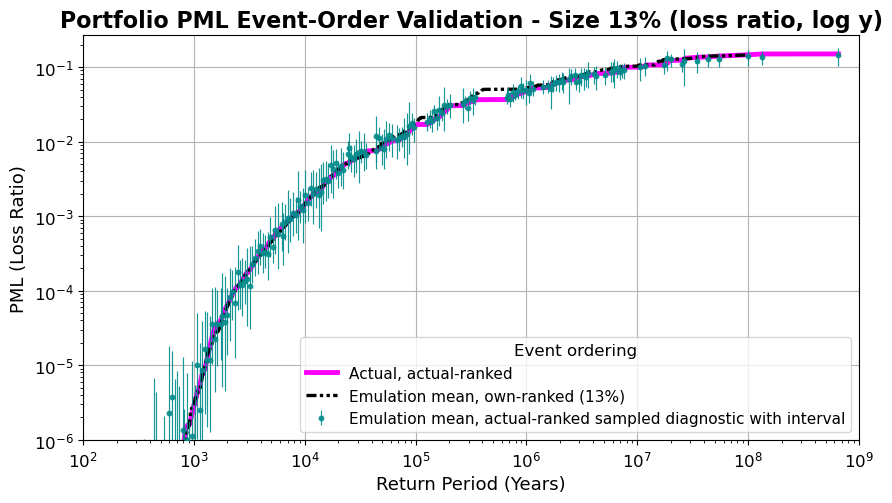

/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/portfolio_pml_event_order_validation_loss_ratio_log_sizes.gif


In [17]:
for validation_y_scale in VALIDATION_Y_SCALES:
    validation_fig, _ = plot_pml_event_order_validation(
        VALIDATION_SIZE,
        y_scale=validation_y_scale,
        save=SAVE_OUTPUTS,
    )

if RUN_VALIDATION_ANIMATION:
    validation_animations = {}
    for validation_y_scale in VALIDATION_Y_SCALES:
        validation_animations[validation_y_scale] = animate_pml_event_order_validation(
            VALIDATION_SIZES,
            y_scale=validation_y_scale,
            save_gif=SAVE_OUTPUTS,
        )
        display(HTML(validation_animations[validation_y_scale].to_jshtml()))
